## Multi-hazard climate risk screening (East Texas power portfolio)

End-to-end multi-hazard climate-risk screening for a small US power-generation portfolio in East Texas, using Emmi's Climate Hazard Diagnostics (CHD) datasets via the Cecil SDK. The heavy lifting lives in the `chd.py` helper in this directory; this notebook composes the helpers into a short, readable workflow.

For a single-asset walkthrough that pulls every variable Emmi publishes across baseline + four RCP scenarios, see [`single-asset-deep-dive.ipynb`](single-asset-deep-dive.ipynb) next to this one.

### What you need

```bash
pip install cecil matplotlib pandas folium
```

A Cecil API key exported in your shell:

```bash
export CECIL_API_KEY="your-key-here"
```

If you'd rather load the key from a `.env` file, see [`tutorials/cecil-data-analysis-xql/scripts/_env.py`](../../tutorials/cecil-data-analysis-xql/scripts/_env.py) for the repo's reference dotenv loader, or use `python-dotenv` directly.

### What the helper provides

* `chd.DATASETS` and `chd.METRICS`: the four CHD UUIDs and the metric catalog.
* `chd.list_variables(...)`: discoverable variable names with filters. Pass `client=client` to also cross-check against the live Cecil catalogue.
* `chd.verify_catalog(client)`: cross-check the hardcoded catalogue against Cecil's live dataset metadata. Useful at session start to spot drift.
* `chd.point_aoi(lat, lon, target_ha)`: latitude-corrected square AOIs.
* `chd.estimate_cost(...)`: bundle-aware cost preview.
* `chd.provision(...)`: creates or reuses AOIs and subscriptions; safe to re-run.
* `chd.load(...)` and `chd.sample(...)`: cacheable I/O and typed sampling.
* `chd.screen(...)`: one-call orchestration. Default: per-asset per-hazard climate-attributable delta in average annual loss under RCP4.5 at 2050. Long-format DataFrame, NaN propagates for missing combos (e.g. RCP2.6 on floods).

### 1. Connect

In [1]:
import os
import logging

import cecil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import chd

# Surface chd's info logs (cost preview, provisioning summary) in the notebook.
logging.basicConfig(level=logging.INFO, format="%(message)s")

assert os.environ.get("CECIL_API_KEY"), "Set CECIL_API_KEY in your environment first."
client = cecil.Client()

### 2. Define the portfolio

Each row is one asset (Powerplants in this example). Replace these with your own assets to apply the notebook to a different portfolio.

**Source:** asset names and coordinates are from [Climate TRACE](https://climatetrace.org)'s `electricity-generation` inventory (CC BY 4.0).

Asset values are illustrative placeholders (Climate TRACE publishes emissions, not financial valuations). To cite the underlying records:

> Freeman, J. et al. (2025). *Power sector: Emissions from Electricity Generation.* WattTime, Pixel Scientia Labs, Global Energy Monitor. Climate TRACE Emissions Inventory v5.4.1. https://climatetrace.org

In [2]:
PORTFOLIO = pd.DataFrame([
    {"name": "Barney M Davis", "lat": 27.606, "lon": -97.312, "value_usd":  1_500_000_000},
    {"name": "W. A. Parish",   "lat": 29.479, "lon": -95.633, "value_usd":  4_000_000_000},
    {"name": "Channelview",    "lat": 29.837, "lon": -95.122, "value_usd":    900_000_000},
    {"name": "Limestone",      "lat": 31.423, "lon": -96.253, "value_usd":  1_800_000_000},
    {"name": "Martin Lake",    "lat": 32.261, "lon": -94.571, "value_usd":  2_200_000_000},
])

PORTFOLIO

,name,lat,lon,value_usd
0,Barney M Davis,27.606,-97.312,1500000000
1,W. A. Parish,29.479,-95.633,4000000000
2,Channelview,29.837,-95.122,900000000
3,Limestone,31.423,-96.253,1800000000
4,Martin Lake,32.261,-94.571,2200000000


### 3. Show the assets on a map

Optional Sanity check the coordinates before subscribing (using folium).

In [3]:
import folium
fig = folium.Figure(width=700, height=450)
m = folium.Map(tiles="OpenStreetMap").add_to(fig)

for _, row in PORTFOLIO.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=7,
        color="white", weight=2,
        fill=True, fill_color="#d62728", fill_opacity=1.0,
        tooltip=folium.Tooltip(row["name"], permanent=True, direction="right"),
    ).add_to(m)

# Auto-fit the view to the portfolio bbox, with a little padding for the labels.
m.fit_bounds(
    [[PORTFOLIO["lat"].min(), PORTFOLIO["lon"].min()],
     [PORTFOLIO["lat"].max(), PORTFOLIO["lon"].max()]],
    padding=(40, 40),
)
fig

### 4. Explore what's available

The helper exposes the dataset UUIDs, the metric catalog, and a `list_variables` query that respects per-hazard scenario availability. Floods only have `baseline / rcp4p5 / rcp8p5`; wildfire and cyclones have all five RCPs.

Passing `client=client` to `chd.list_variables` (or calling `chd.verify_catalog(client)` directly) cross-checks the hardcoded catalogue against Cecil's live dataset metadata and logs a warning on any drift. Good to run at session start in case Emmi has shipped new variables since the helper was last updated.

In [4]:
print("Datasets:", list(chd.DATASETS.keys()))
print()
print("Metrics (hazards that publish each):")
for name, hazards in chd.METRICS.items():
    print(f"  {name:22}  {hazards}")
print()
# Passing `client` triggers an automatic cross-check; drift is logged as warnings.
print("Variables on wildfire (verified against live Cecil catalogue):")
for v in chd.list_variables(hazard="wildfire", client=client):
    print(f"  {v}")

Datasets: ['wildfire', 'cyclones', 'coastal_floods', 'fluvial_floods']

Metrics (hazards that publish each):
  average_annual_loss     ['wildfire', 'cyclones', 'coastal_floods', 'fluvial_floods']
  intensity               ['wildfire', 'cyclones', 'coastal_floods', 'fluvial_floods']
  probability             ['wildfire', 'cyclones', 'coastal_floods', 'fluvial_floods']
  fire_danger_days        ['wildfire']
  wind_speed_mps          ['cyclones']
  depth_meters            ['coastal_floods', 'fluvial_floods']

Variables on wildfire (verified against live Cecil catalogue):
  average_annual_loss_baseline
  average_annual_loss_rcp2p6
  average_annual_loss_rcp4p5
  average_annual_loss_rcp6p0
  average_annual_loss_rcp8p5
  fire_danger_days_baseline
  fire_danger_days_rcp2p6
  fire_danger_days_rcp4p5
  fire_danger_days_rcp6p0
  fire_danger_days_rcp8p5
  intensity_baseline
  intensity_rcp2p6
  intensity_rcp4p5
  intensity_rcp6p0
  intensity_rcp8p5
  probability_baseline
  probability_rcp2p6
  pro

### 5. Cost estimate and provision

Preview the cost, then create the AOIs and subscriptions once. The helper assumes bundle pricing (one $/ha covers all four CHD datasets). Re-running `chd.provision()` is a no-op: it matches by `external_ref` and reuses anything already on the account.

We also create an empty `cache` dict here. Every `chd.screen()` call below shares it, so each subscription downloads once across the whole notebook instead of once per call.

In [5]:
chd.estimate_cost(PORTFOLIO, target_ha=1.0)

# Create AOIs + subscriptions once. Safe to re-run.
subs = chd.provision(client, PORTFOLIO, target_ha=1.0, tag="emmi-chd-example")

# Shared xarray cache: each subscription downloads once across all chd.screen() calls below.
cache = {}

Per-asset AOI area: 1.000 ha
Assets: 5, hazards bundled into one $/ha charge
Total billable hectares: 5.000
Entry tier        @ $5.0/ha: $   25.00
Subscription tier @ $0.5/ha: $    2.50
  = AOI reused    Barney M Davis               (1.002 ha)
  = AOI reused    W. A. Parish                 (1.002 ha)
  = AOI reused    Channelview                  (1.002 ha)
  = AOI reused    Limestone                    (1.003 ha)
  = AOI reused    Martin Lake                  (1.003 ha)
AOIs:            5 total  (0 new, 5 reused)
Subscriptions:  20 total  (0 new, 20 reused)


### 6. Screen the portfolio

One call. `chd.screen()` loads each subscription once (cached), samples baseline and the chosen future scenario, and returns a long-format DataFrame with one row per `(asset, scenario, year, metric)`. Columns: `name[, value_usd], scenario, year, metric, wildfire, cyclones, coastal_floods, fluvial_floods, total[, total_usd]`.

By default `delta=True`, so each hazard column holds the climate-attributable change (`future - baseline`). NaN propagates: any missing combo (e.g. `rcp2p6` on floods) makes that cell NaN, and `total` is NaN if any hazard cell is NaN. Baseline rows always return absolute values regardless of `delta`.

If your portfolio has a `value_usd` column, the output adds a `total_usd` column (`total` × `value_usd`). Otherwise the dollar columns are skipped.

`scenario`, `year`, and `metric` accept lists too — see sections 10 and 11. We pass the `subs` and `cache` from section 5 so this and the later screens share state.

In [6]:
SCENARIO = "rcp4p5"   # one of: rcp2p6, rcp4p5, rcp6p0, rcp8p5 (floods only have rcp4p5/rcp8p5)
SCENARIO_YEAR = 2050  # one of: 2030, 2050, 2080

risk = chd.screen(
    client, PORTFOLIO,
    scenario=SCENARIO, year=SCENARIO_YEAR,
    metric="average_annual_loss",
    delta=True,
    subs=subs, cache=cache,
    require_confirmation=False,
)

risk.sort_values("total_usd", ascending=False)

,name,value_usd,scenario,year,metric,wildfire,cyclones,coastal_floods,fluvial_floods,total,total_usd
1,W. A. Parish,4000000000,rcp4p5,2050,average_annual_loss,0.000110,1.236606e-02,0.0,-0.000058,0.012419,4.967468e+07
0,Barney M Davis,1500000000,rcp4p5,2050,average_annual_loss,0.000018,2.237038e-02,0.0,0.000000,0.022388,3.358236e+07
2,Channelview,900000000,rcp4p5,2050,average_annual_loss,0.000465,1.135418e-02,0.0,-0.000058,0.011761,1.058488e+07
4,Martin Lake,2200000000,rcp4p5,2050,average_annual_loss,0.002963,5.855761e-08,0.0,0.000000,0.002963,6.519415e+06
3,Limestone,1800000000,rcp4p5,2050,average_annual_loss,0.001342,1.915760e-07,0.0,0.000000,0.001342,2.415734e+06


### 7. Per-hazard delta AAL

One panel per hazard. Each bar is the climate-attributable change in AAL for one asset under the selected scenario at the selected year. NaN cells appear as gaps (e.g. cyclone or coastal-flood AAL for an inland asset).

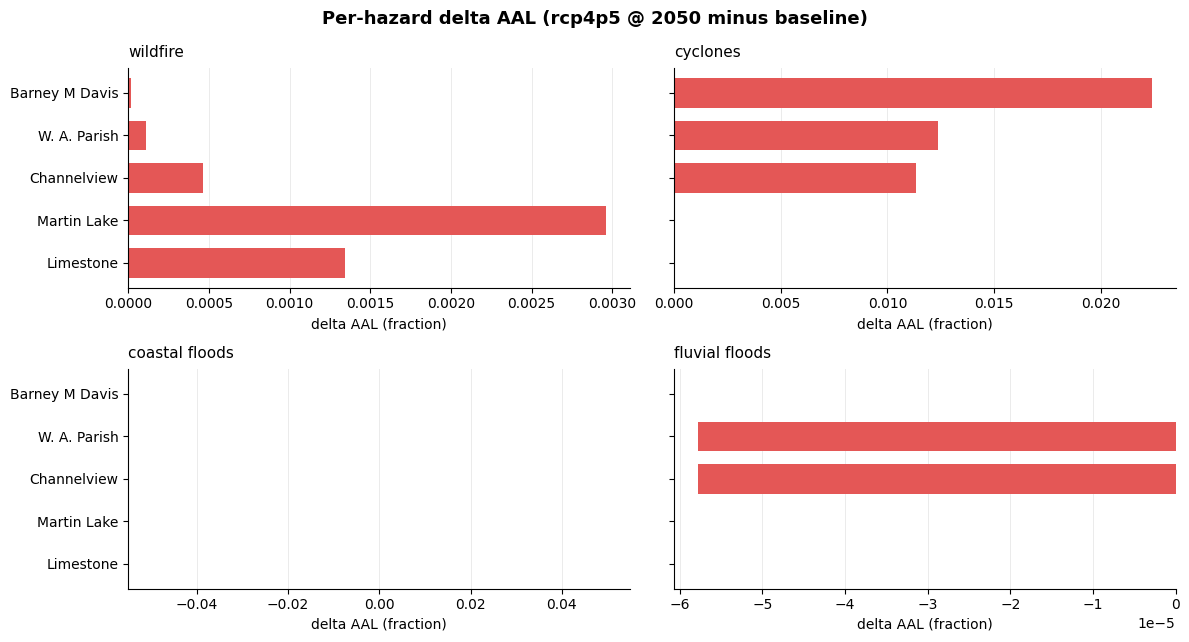

In [7]:
DELTA_COLOR = "#e45756"   # Vega red

# Filter to one (scenario, year, metric) so the chart has one bar per asset per panel.
plot_df = risk[
    (risk["scenario"] == SCENARIO)
    & (risk["year"] == SCENARIO_YEAR)
    & (risk["metric"] == "average_annual_loss")
]

hazards = list(chd.DATASETS.keys())
order = plot_df.sort_values("total", ascending=True, na_position="first")["name"].tolist()
df = plot_df.set_index("name").loc[order]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.5), sharey=True)
for ax, hazard in zip(axes.flatten(), hazards):
    values = df[hazard]
    y = np.arange(len(order))
    ax.barh(y, values.fillna(0), height=0.7, color=DELTA_COLOR)
    ax.set_yticks(y)
    ax.set_yticklabels(order)
    ax.set_title(hazard.replace("_", " "), fontsize=11, loc="left", pad=8)
    ax.set_xlabel("delta AAL (fraction)")
    ax.grid(axis="x", color="0.92", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

fig.suptitle(f"Per-hazard delta AAL ({SCENARIO} @ {SCENARIO_YEAR} minus baseline)",
             fontsize=13, fontweight="semibold")
plt.tight_layout()
plt.show()

### 8. Total delta EAL by asset

Total delta AAL across all four hazards, multiplied by asset value. This is the headline portfolio-level number: dollars of climate-attributable expected annual loss.

Note: `total` is NaN-propagating, so the same applies to `total_usd`. Assets with any NaN hazard cell are dropped from this chart.

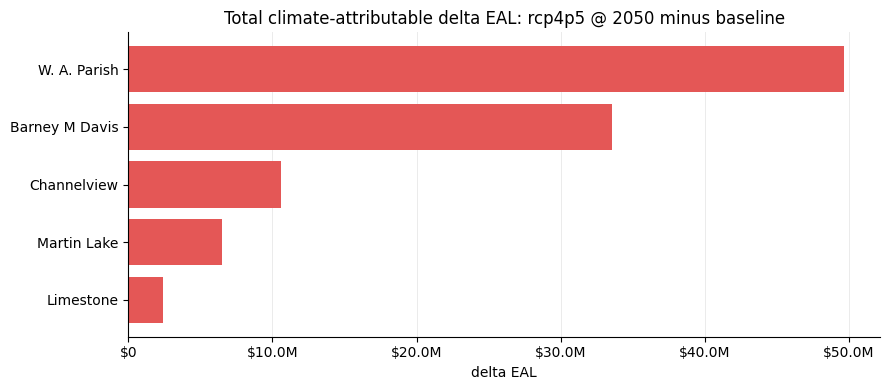

In [8]:
def _fmt_usd(x, _pos=None):
    if abs(x) >= 1e9:
        return f"${x/1e9:.1f}B"
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}K"
    return f"${x:,.0f}"

ranked = (
    risk[
        (risk["scenario"] == SCENARIO)
        & (risk["year"] == SCENARIO_YEAR)
        & (risk["metric"] == "average_annual_loss")
    ]
    .dropna(subset=["total_usd"])
    .sort_values("total_usd", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(ranked))
ax.barh(y, ranked["total_usd"], color=DELTA_COLOR)
ax.set_yticks(y)
ax.set_yticklabels(ranked["name"])
ax.set_xlabel("delta EAL")
ax.xaxis.set_major_formatter(plt.FuncFormatter(_fmt_usd))
ax.set_title(f"Total climate-attributable delta EAL: {SCENARIO} @ {SCENARIO_YEAR} minus baseline")
ax.grid(axis="x", color="0.92", linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### 9. Portfolio composition: baseline + 2050 RCP4.5 per hazard

A single-ring donut, eight slices: for each hazard, the value-weighted mean baseline AAL (darker) plus the climate-attributable increase to RCP4.5 @ 2050 (lighter). The centre carries the portfolio's total AAL at 2050 and the delta vs baseline. Adapted from the Holcim multi-hazard chart in `emmi-methodologies/scripts/blog_holcim_multi_hazard_charts.py`.

Value-weighted means each asset contributes proportionally to its `value_usd`, which matches how an EAL number would be aggregated. With the illustrative placeholder values here it's a portfolio-shape demo; with real valuations it would be your headline number.

In [9]:
# Get absolute baseline and 2050 RCP4.5 values (one screen call, delta off).
abs_risk = chd.screen(
    client, PORTFOLIO,
    scenario=["baseline", "rcp4p5"], year=2050,
    metric="average_annual_loss",
    delta=False,
    subs=subs, cache=cache,
    require_confirmation=False,
)

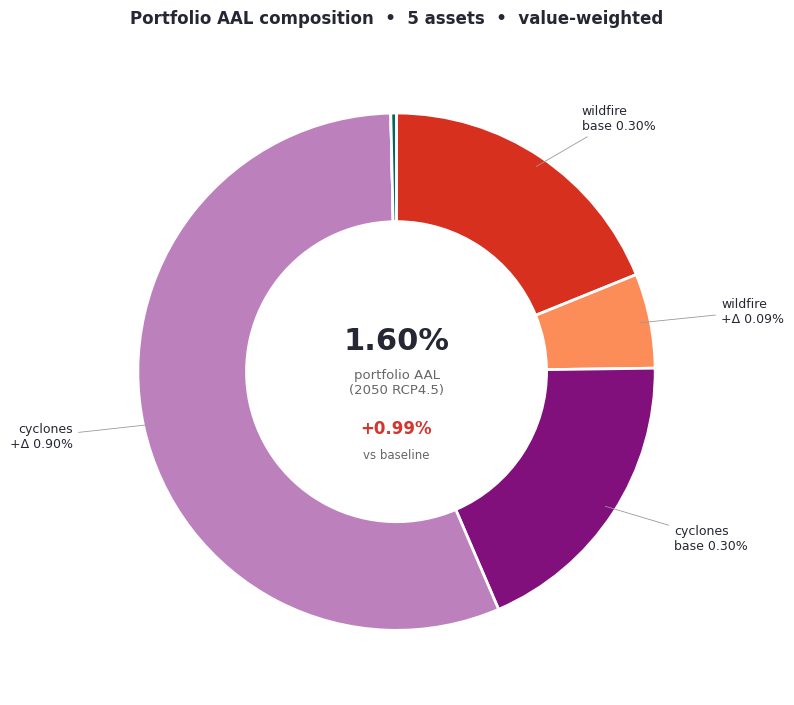

In [10]:
# Plot Donut chart with Emmi hazard colours
HAZARD_BASE = {
    "wildfire":       "#d7301f",
    "cyclones":       "#810f7c",
    "coastal_floods": "#0868ac",
    "fluvial_floods": "#01665e",
}
HAZARD_DELTA = {
    "wildfire":       "#fc8d59",
    "cyclones":       "#bc80bd",
    "coastal_floods": "#80b1d3",
    "fluvial_floods": "#8dd3c7",
}
CHARCOAL = "#252734"

def weighted_mean(scenario):
    """Value-weighted mean AAL across the portfolio, per hazard. NaN -> 0."""
    sub = abs_risk[abs_risk["scenario"] == scenario]
    w = sub["value_usd"].fillna(0).to_numpy()
    return {h: float((sub[h].fillna(0).to_numpy() * w).sum() / w.sum())
            for h in chd.DATASETS}

baseline = weighted_mean("baseline")
rcp45    = weighted_mean("rcp4p5")
deltas   = {h: max(0.0, rcp45[h] - baseline[h]) for h in chd.DATASETS}

# Build 8 slices: baseline + delta per hazard. Values in % for label readability.
hazards = list(chd.DATASETS.keys())
values, colors, labels = [], [], []
for h in hazards:
    values.append(baseline[h] * 100)
    colors.append(HAZARD_BASE[h])
    labels.append(f"{h.replace('_', ' ')}\nbase {baseline[h]*100:.2f}%")
    values.append(deltas[h] * 100)
    colors.append(HAZARD_DELTA[h])
    labels.append(f"{h.replace('_', ' ')}\n+Δ {deltas[h]*100:.2f}%")

total_base  = sum(baseline.values()) * 100
total_2050  = sum(rcp45.values())    * 100
total_delta = total_2050 - total_base

fig, ax = plt.subplots(figsize=(8, 8))
wedges, _ = ax.pie(
    values, colors=colors,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
)

# External labels for non-trivial slices (skip tiny slivers).
slice_total = sum(values) or 1
for i, w in enumerate(wedges):
    if values[i] / slice_total < 0.015:
        continue
    ang = (w.theta2 + w.theta1) / 2
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    ax.annotate(
        labels[i],
        xy=(x*0.95, y*0.95), xytext=(x*1.28, y*1.18),
        ha="center" if abs(x) < 0.4 else ("left" if x > 0 else "right"),
        va="center", fontsize=9, color=CHARCOAL,
        arrowprops=dict(arrowstyle="-", color="#999", lw=0.6),
    )

# Centre annotation.
ax.text(0,  0.12, f"{total_2050:.2f}%", ha="center", va="center", fontsize=22, weight="bold", color=CHARCOAL)
ax.text(0, -0.04, "portfolio AAL\n(2050 RCP4.5)", ha="center", va="center", fontsize=9.5, color="#666")
ax.text(0, -0.22, f"+{total_delta:.2f}%", ha="center", va="center", fontsize=12, weight="bold", color="#d6342d")
ax.text(0, -0.32, "vs baseline", ha="center", va="center", fontsize=8.5, color="#666")

ax.set_title(f"Portfolio AAL composition  •  {len(PORTFOLIO)} assets  •  value-weighted",
             fontsize=12, weight="bold", color=CHARCOAL, pad=18)
plt.tight_layout()
plt.show()

### 10. Drill into one subscription

For ad-hoc exploration after the headline screen. Load one (asset, hazard) dataset once and sample any variable across any scenario or year.

In [11]:
sub = subs["W. A. Parish"]["wildfire"]
ds = chd.load(client, sub, cache=cache)

print(f"Today's AAL:              {chd.sample(ds, 'average_annual_loss_baseline'):.4f}")
print(f"Today's fire danger days: {chd.sample(ds, 'fire_danger_days_baseline'):.1f}")
print(f"Today's intensity:        {chd.sample(ds, 'intensity_baseline'):.4f}")
print()
print("RCP8.5 AAL trajectory:")
for year in [2030, 2050, 2080]:
    aal = chd.sample(ds, "average_annual_loss_rcp8p5", year=year)
    print(f"  {year}: {aal:.4f}")

Today's AAL:              0.0001
Today's fire danger days: 21.0
Today's intensity:        0.0370

RCP8.5 AAL trajectory:
  2030: 0.0002
  2050: 0.0002
  2080: 0.0003


### 11. Climate trajectory: how does AAL evolve under each RCP?

Sweep all four future scenarios across 2030, 2050, 2080 in one call. The result has one row per `(asset, scenario, year)`. Line plot per asset shows the four RCPs diverging through the century.

> **Why RCP6.0 sometimes dips below RCP4.5:** the RCPs are radiative-forcing pathways, not strictly-ordered warming trajectories. RCP6.0 back-loads emissions, so mid-century (2030/2050) forcing is *lower* than RCP4.5; the ordering only locks in by 2080. Non-monotonic crossings are a real feature of the underlying CMIP6 models, not a data bug.

In [12]:
trajectory = chd.screen(
    client, PORTFOLIO,
    scenario=["rcp2p6", "rcp4p5", "rcp6p0", "rcp8p5"],
    year=[2030, 2050, 2080],
    metric="average_annual_loss",
    delta=True,
    subs=subs, cache=cache,
    require_confirmation=False,
)

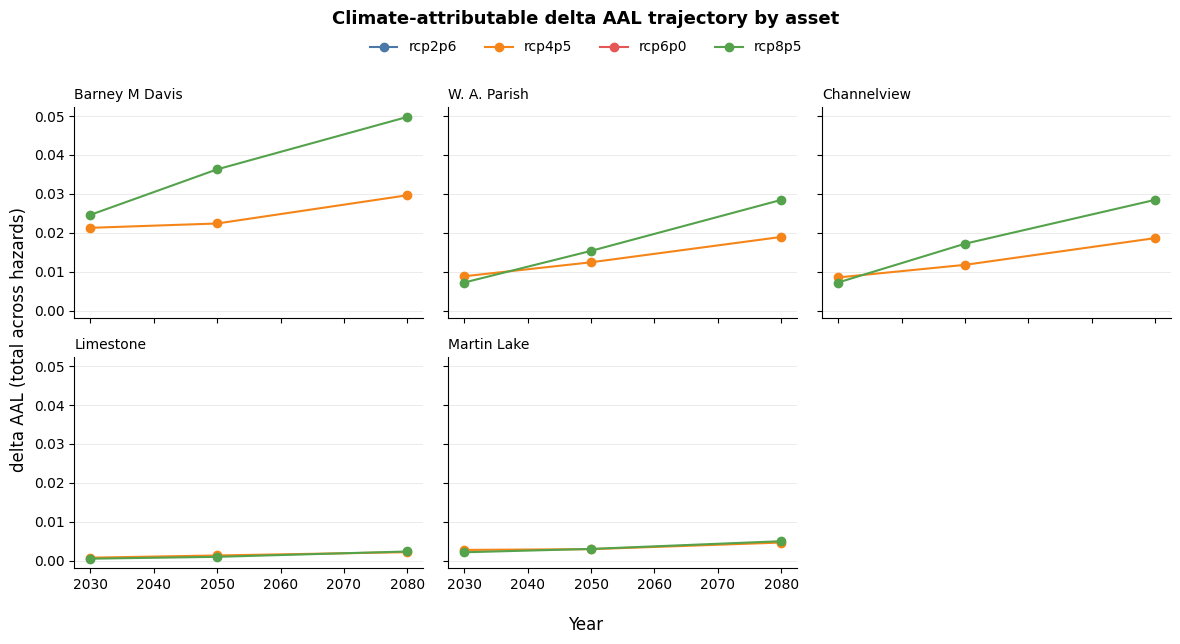

In [13]:
SCENARIO_COLORS = {
    "rcp2p6": "#4c78a8",
    "rcp4p5": "#f58518",
    "rcp6p0": "#e45756",
    "rcp8p5": "#54a24b",
}

assets = PORTFOLIO["name"].tolist()
ncols = 3
nrows = (len(assets) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 3 * nrows), sharey=True, sharex=True)
axes = axes.flatten()

for ax, asset_name in zip(axes, assets):
    asset_data = trajectory[trajectory["name"] == asset_name]
    for s, color in SCENARIO_COLORS.items():
        s_data = asset_data[asset_data["scenario"] == s].sort_values("year")
        ax.plot(s_data["year"], s_data["total"], marker="o", linewidth=1.5, color=color, label=s)
    ax.set_title(asset_name, fontsize=10, loc="left")
    ax.grid(axis="y", color="0.92", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

for ax in axes[len(assets):]:
    ax.set_visible(False)

handles = [
    plt.Line2D([0], [0], color=c, marker="o", linewidth=1.5, label=s)
    for s, c in SCENARIO_COLORS.items()
]
fig.legend(handles=handles, loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Climate-attributable delta AAL trajectory by asset", fontsize=13, fontweight="semibold", y=1.05)
fig.supxlabel("Year")
fig.supylabel("delta AAL (total across hazards)")
plt.tight_layout()
plt.show()

### Next steps

* **Sweep different metrics.** Pass `metric=["average_annual_loss", "intensity", "probability"]` to `chd.screen()` to compare physical and economic measures side by side.
* **Use your own portfolio.** Replace the rows in `PORTFOLIO` with real assets and values, then re-run from section 2. Add a `value_usd` column to get `total_usd` in the output, or omit it if you only want hazard fractions.
* **Drill into one variable.** Section 10 shows `chd.load()` + `chd.sample()` for ad-hoc exploration of any variable in `chd.list_variables()`.